<a href="https://colab.research.google.com/github/Nakib-Nasrullah/Dengue_Research/blob/main/Dengue_XGBOST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Imoort libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import xgboost
import tensorflow


In [5]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/Dengue_final_dataset_updated.csv')

In [8]:
# Convert date
df['S'] = pd.to_datetime(df['S'])

# Sort properly
df = df.sort_values(['District', 'S'])

## Handle Missing **Values**

In [9]:
df = df.fillna(method='bfill').fillna(method='ffill')


# **Feature Selection (Automatic - XGBoost Importance)**

In [11]:
from xgboost import XGBRegressor
import numpy as np

features = [
    'Max_Temp', 'Rainfall_Lag_7','Rainfall_Lag_14','Rainfall_Lag_21',
    'Rainfall_Lag_30','Temp_Lag_7','Rainfall', 'Humidity','Humidity_Lag_7',
    'Humidity_Lag_14','Humidity_Lag_21','Humidity_Lag_30',
    'Dengue_Lag_7', 'Population_Density','Urban_Index'
]

target = 'Dengue_case'

X = df[features]
y = df[target]

model = XGBRegressor()
model.fit(X, y)

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

# Select top features
selected_features = feature_importance['Feature'].head(6).tolist()
print("Selected Features:", selected_features)


               Feature  Importance
13  Population_Density    0.307614
4      Rainfall_Lag_30    0.184246
8       Humidity_Lag_7    0.109049
14         Urban_Index    0.098762
6             Rainfall    0.078174
7             Humidity    0.049862
3      Rainfall_Lag_21    0.026940
1       Rainfall_Lag_7    0.026534
11     Humidity_Lag_30    0.025300
10     Humidity_Lag_21    0.023762
5           Temp_Lag_7    0.023489
12        Dengue_Lag_7    0.017630
0             Max_Temp    0.011696
2      Rainfall_Lag_14    0.009237
9      Humidity_Lag_14    0.007705
Selected Features: ['Population_Density', 'Rainfall_Lag_30', 'Humidity_Lag_7', 'Urban_Index', 'Rainfall', 'Humidity']


# **Train XGBoost Model**

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

X = df[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("XGBoost RMSE:", rmse)
print("XGBoost MAE:", mae)


XGBoost RMSE: 35.25046403728255
XGBoost MAE: 10.917937278747559


# **LSTM Model (Time Series)**

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[selected_features + [target]])

def create_sequences(data, seq_length=14):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :-1])
        y.append(data[i+seq_length, -1])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(scaled_data)


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_seq.shape[1], X_seq.shape[2])),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_seq, y_seq, epochs=10, batch_size=32)


Epoch 1/10
730/730 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.0017
Epoch 2/10
730/730 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - loss: 0.0016
Epoch 3/10
730/730 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - loss: 0.0015
Epoch 4/10
730/730 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 0.0015
Epoch 5/10
730/730 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0015
Epoch 6/10
730/730 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - loss: 0.0015
Epoch 7/10
730/730 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 0.0014
Epoch 8/10
730/730 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0015
Epoch 9/10
730/730 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0015
Epoch 10/10
730/730 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0014


# **Evaluate LSTM**

In [15]:
y_pred_lstm = model.predict(X_seq)

rmse_lstm = np.sqrt(mean_squared_error(y_seq, y_pred_lstm))
mae_lstm = mean_absolute_error(y_seq, y_pred_lstm)

print("LSTM RMSE:", rmse_lstm)
print("LSTM MAE:", mae_lstm)

730/730 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step
LSTM RMSE: 0.03173986070015921
LSTM MAE: 0.012364429031338125


# **Future Prediction (Next 7 Days)**

In [17]:
last_sequence = X_seq[-1].reshape(1, X_seq.shape[1], X_seq.shape[2])

future_preds = []

for _ in range(7):
    pred = model.predict(last_sequence)[0][0]
    future_preds.append(pred)

    # shift sequence
    last_sequence = np.roll(last_sequence, -1, axis=1)
    last_sequence[0, -1, -1] = pred

print("Next 7 Days Predictions:", future_preds)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Next 7 Days Predictions: [np.float32(0.002031725), np.float32(0.0032307468), np.float32(0.004416514), np.float32(0.0054504536), np.float32(0.006201118), np.float32(0.0069032386), np.float32(0.0074546784)]


# **Visualization**

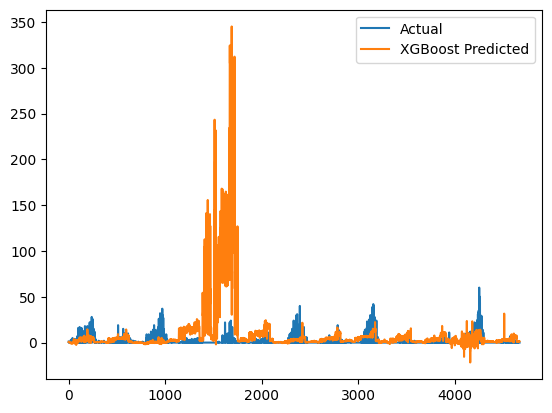

In [18]:
import matplotlib.pyplot as plt

plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='XGBoost Predicted')
plt.legend()
plt.show()